# 08 · Risk-signal engine and integrated score
**Design:** transparent rules (label-free development quantiles) + an integrated score whose weights are fitted by a
logistic model constrained to non-negative weights, on development weeks of a random half of accounts (group 0).
Candidate scoring methods were compared on the *other* half of accounts in development weeks (validation) before
the test period was touched.

In [1]:
import sys, json, sqlite3
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import config
pd.set_option("display.width", 180); pd.set_option("display.max_columns", 30); pd.set_option("display.precision", 4)
T = lambda name: pd.read_csv(config.TABLES_DIR / f"{name}.csv")
KM = json.loads((config.TABLES_DIR / "key_metrics.json").read_text())
con = sqlite3.connect(config.DB_PATH)
def show(fig_name, width=11):
    img = plt.imread(config.FIGURES_DIR / f"{fig_name}.png")
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w)); ax.imshow(img); ax.axis("off")
print("outputs loaded from", config.TABLES_DIR.relative_to(ROOT))

outputs loaded from outputs/tables


In [2]:
T("model_selection_dev_validation")[["approach", "pr_auc", "roc_auc", "precision_top5pct", "transferable_by_design"]]

,approach,pr_auc,roc_auc,precision_top5pct,transferable_by_design
0,M0 Velocity only (weekly count),0.3479,0.7389,0.5082,True
1,M1 Evidence count (families fired),0.3158,0.7249,0.5327,True
2,M2 Integrated non-negative logistic,0.3673,0.7344,0.5714,True
3,ML1 Logistic regression (unconstrained),0.5208,0.7733,0.6939,False
4,ML2 Gradient boosting,0.4952,0.7598,0.6531,False
5,ML3 Isolation Forest (unsupervised),0.2853,0.7319,0.4020,False


In [3]:
print("selected transferable method:", KM["selected_method"])
w = json.loads((config.MODELS_DIR / "integrated_risk_model.json").read_text())
pd.Series(w["weights"], name="non-negative weight").sort_values(ascending=False)

selected transferable method: M2 Integrated non-negative logistic


,non-negative weight
n_tx,0.7158
velocity_ratio,0.1230
cycle_count,0.0320
fan_out_28,0.0158
max_amt,0.0000
rapid_movement,0.0000
new_cp,0.0000
fan_in_28,0.0000
pagerank_28,0.0000


### Why the unconstrained model is not used

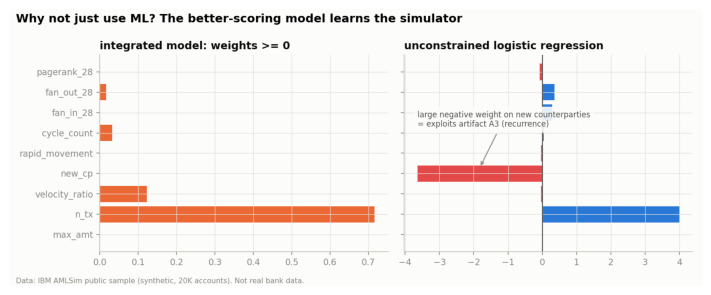

,feature,unconstrained_lr_coef,integrated_nonneg_weight
0,max_amt,0.0189,0.0000
1,n_tx,4.0021,0.7158
2,velocity_ratio,-0.0361,0.1230
3,new_cp,-3.6452,0.0000
4,rapid_movement,-0.0416,0.0000
5,cycle_count,0.0423,0.0320
6,fan_in_28,0.2891,0.0000
7,fan_out_28,0.3496,0.0158
8,pagerank_28,-0.0758,0.0000


In [4]:
show("fig16_why_not_ml", 10)
T("model_coefficients")

### Priority tiers and evidence strength (risk kept separate from confidence)

In [5]:
print("tier cut-offs (risk score):", KM["tier_cutoffs"])
T("evidence_definition_selection")

tier cut-offs (risk score): {'CRITICAL': 99.90046576915715, 'HIGH': 99.70012122758885, 'MEDIUM': 99.40024245517769, 'LOW': 99.00082945192369}


,definition,level,dev_alerts,dev_precision,chosen
0,breadth: signal families fired,Limited,25,1.0000,False
1,breadth: signal families fired,Moderate,120,0.8167,False
2,breadth: signal families fired,Strong,288,0.6389,False
3,persistence: alerted weeks to date,Limited,234,0.6966,True
4,persistence: alerted weeks to date,Moderate,57,0.7368,True
5,persistence: alerted weeks to date,Strong,142,0.7183,True


In [6]:
T("priority_tier_validation")

,risk_level,alerts,precision,accounts,share_of_alerts,alerts_per_week
0,CRITICAL,14,1.0000,4,0.0651,1.5556
1,HIGH,32,0.8438,14,0.1488,3.5556
2,MEDIUM,74,0.8919,61,0.3442,8.2222
3,LOW,95,0.8316,86,0.4419,10.5556


In [7]:
T("evidence_strength_validation")

,evidence_strength,alerts,precision
0,Limited,111,0.8559
1,Moderate,17,0.8235
2,Strong,87,0.8851


In [8]:
T("alert_queue")[["alert_id", "account_id", "risk_level", "risk_score", "evidence_strength", "risk_category",
                    "primary_signal", "evidence"]].sort_values("risk_score", ascending=False).head(8)

,alert_id,account_id,risk_level,risk_score,evidence_strength,risk_category,primary_signal,evidence
864,ALT-W14-09998,9998,CRITICAL,100.000,Strong,Velocity anomaly,VEL-01 High absolute velocity,weekly transaction count = 36 (contribution +6.04) [VEL-01 fired] | circular-flow participation = 4 (contribution +0.81) [AML-03 fired] | distinct receivers (28d) = 55 (contribution +0.09) [NET-02 fired] | velocity vs own history = 1.779 (contribution +0.07)
865,ALT-W14-19993,19993,CRITICAL,100.000,Strong,Velocity anomaly,VEL-01 High absolute velocity,weekly transaction count = 36 (contribution +6.04) [VEL-01 fired] | velocity vs own history = 3.758 (contribution +0.36) [BEH-01 fired] | circular-flow participation = 1 (contribution +0.35) [AML-03 fired] | distinct receivers (28d) = 27 (contribution +0.07) [NET-02 fired]
956,ALT-W15-09998,9998,CRITICAL,100.000,Strong,Velocity anomaly,VEL-01 High absolute velocity,weekly transaction count = 33 (contribution +5.85) [VEL-01 fired] | circular-flow participation = 4 (contribution +0.81) [AML-03 fired] | distinct receivers (28d) = 55 (contribution +0.09) [NET-02 fired] | velocity vs own history = 1.527 (contribution +0.02)
172,ALT-W08-09984,9984,CRITICAL,100.000,Strong,Velocity anomaly,VEL-01 High absolute velocity,weekly transaction count = 32 (contribution +5.79) [VEL-01 fired] | circular-flow participation = 3 (contribution +0.70) [AML-03 fired] | velocity vs own history = 2.176 (contribution +0.14) | distinct receivers (28d) = 28 (contribution +0.07) [NET-02 fired]
1054,ALT-W16-19998,19998,CRITICAL,99.999,Strong,Velocity anomaly,VEL-01 High absolute velocity,weekly transaction count = 36 (contribution +6.04) [VEL-01 fired] | circular-flow participation = 1 (contribution +0.35) [AML-03 fired] | velocity vs own history = 2.011 (contribution +0.12) | distinct receivers (28d) = 56 (contribution +0.09) [NET-02 fired]
1219,ALT-W18-19998,19998,CRITICAL,99.999,Strong,Velocity anomaly,VEL-01 High absolute velocity,weekly transaction count = 33 (contribution +5.85) [VEL-01 fired] | circular-flow participation = 2 (contribution +0.55) [AML-03 fired] | distinct receivers (28d) = 56 (contribution +0.09) [NET-02 fired] | velocity vs own history = 1.606 (contribution +0.04)
173,ALT-W08-09987,9987,CRITICAL,99.999,Strong,Velocity anomaly,VEL-01 High absolute velocity,weekly transaction count = 24 (contribution +5.17) [VEL-01 fired] | circular-flow participation = 8 (contribution +1.10) [AML-03 fired] | velocity vs own history = 1.966 (contribution +0.11) | distinct receivers (28d) = 28 (contribution +0.07) [NET-02 fired]
1055,ALT-W16-09998,9998,CRITICAL,99.997,Strong,Velocity anomaly,VEL-01 High absolute velocity,weekly transaction count = 32 (contribution +5.79) [VEL-01 fired] | circular-flow participation = 2 (contribution +0.55) [AML-03 fired] | distinct receivers (28d) = 55 (contribution +0.09) [NET-02 fired] | velocity vs own history = 1.419 (contribution +0.00)
